# Comparing methods of hurricane forecast uncertainty
##### author: Elizabeth A. Barnes, Randal J. Barnes and Mark DeMaria

In [1]:
import datetime
import os
import pickle
import pprint
import time

import experiment_settings
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from build_data import build_hurricane_data
import build_model
from model_diagnostics import plot_history
from save_model_run import save_model_run
from sklearn import preprocessing
from training_instrumentation import TrainingInstrumentation
from silence_tensorflow import silence_tensorflow
import tensorflow_probability as tfp
import random
import imp

silence_tensorflow()

tf.config.set_visible_devices([], 'GPU') # turn-off tensorflow-metal if it is on

In [2]:
__author__ = "Randal J Barnes and Elizabeth A. Barnes"
__version__ = "v1.0.1, 27 July 2022"

imp.reload(experiment_settings)
EXP_NAME_LIST = (
    # "longitude402_AL48",
    # "latitude402_AL48",
    "longitude501_EPCP24",
    "latitude501_EPCP24",
    # "longitude404_AL96",
    # "latitude404_AL96",    
)

OVERWRITE_MODEL = False
DATA_PATH = "../data/"
MODEL_PATH = "saved_models/"

In [3]:
mpl.rcParams["figure.facecolor"] = "white"
mpl.rcParams["figure.dpi"] = 150
np.warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning)

## Start looping through runs

'longitude501_EPCP24_2013_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 1121.
Epoch 01371: early stopping
{'best_epoch': 1120,
 'elapsed_time': 40.01071906089783,
 'loss_train': 5.230783939361572,
 'loss_valid': 5.243319034576416,
 'network_seed': 123}


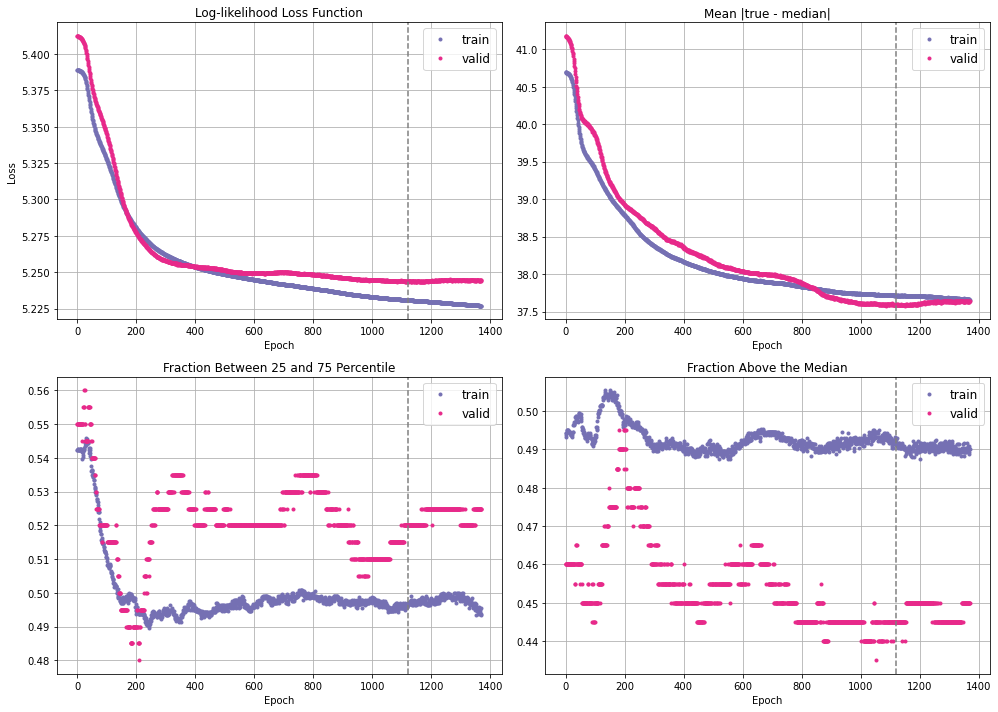

'longitude501_EPCP24_2013_shash2_network_seed_234_rng_seed_234'
Restoring model weights from the end of the best epoch: 1236.
Epoch 01486: early stopping
{'best_epoch': 1235,
 'elapsed_time': 40.48924970626831,
 'loss_train': 5.242246150970459,
 'loss_valid': 5.190990447998047,
 'network_seed': 234}


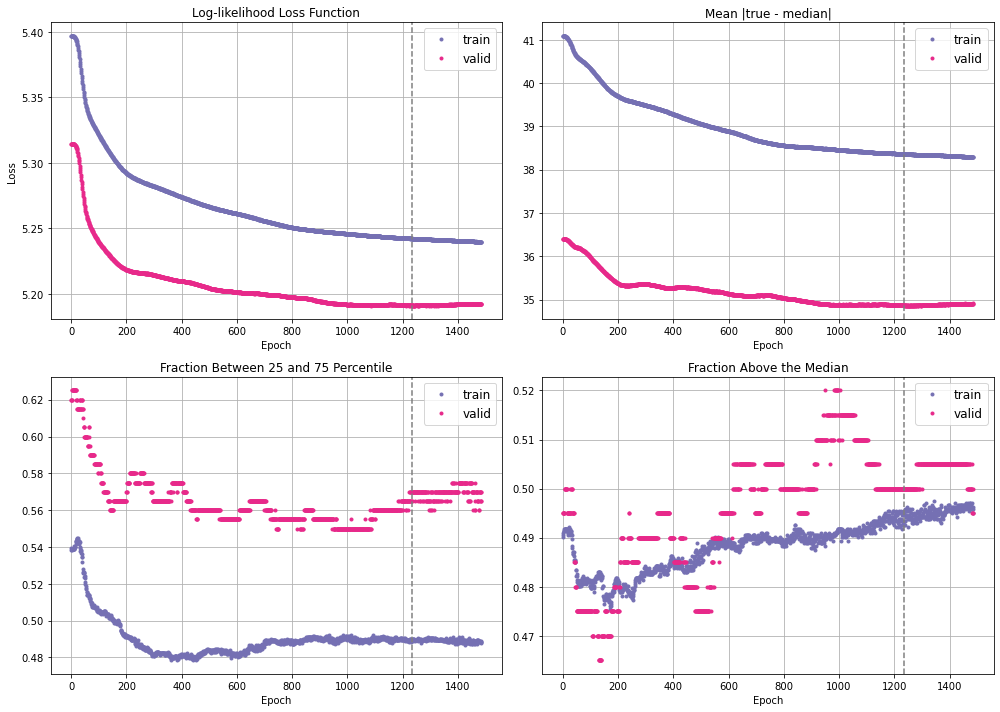

'longitude501_EPCP24_2013_shash2_network_seed_345_rng_seed_345'
Restoring model weights from the end of the best epoch: 927.
Epoch 01177: early stopping
{'best_epoch': 926,
 'elapsed_time': 31.992321014404297,
 'loss_train': 5.237852096557617,
 'loss_valid': 5.19590950012207,
 'network_seed': 345}


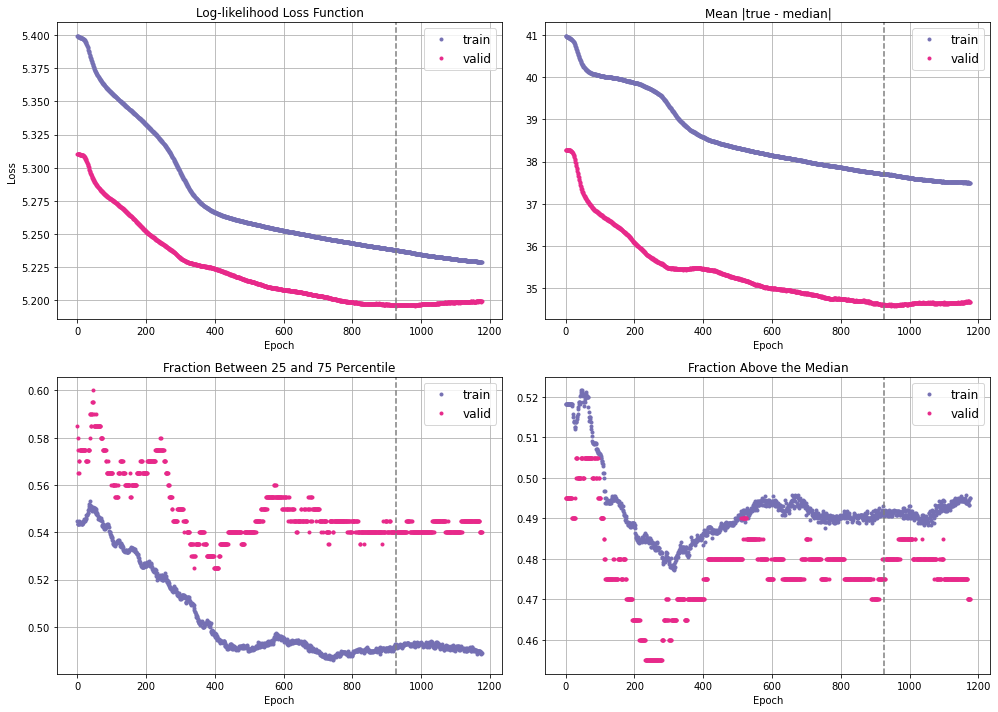

'longitude501_EPCP24_2014_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 2878.
Epoch 03128: early stopping
{'best_epoch': 2877,
 'elapsed_time': 83.75364303588867,
 'loss_train': 5.221717834472656,
 'loss_valid': 5.24050760269165,
 'network_seed': 123}


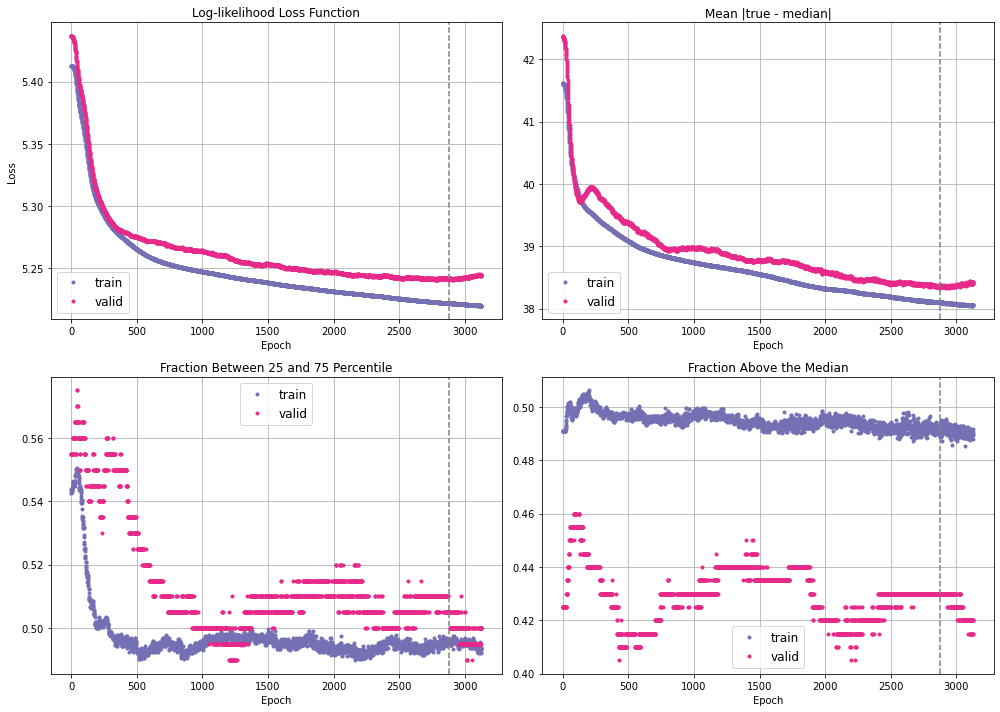

'longitude501_EPCP24_2014_shash2_network_seed_234_rng_seed_234'
Restoring model weights from the end of the best epoch: 936.
Epoch 01186: early stopping
{'best_epoch': 935,
 'elapsed_time': 32.02571702003479,
 'loss_train': 5.247413635253906,
 'loss_valid': 5.2578511238098145,
 'network_seed': 234}


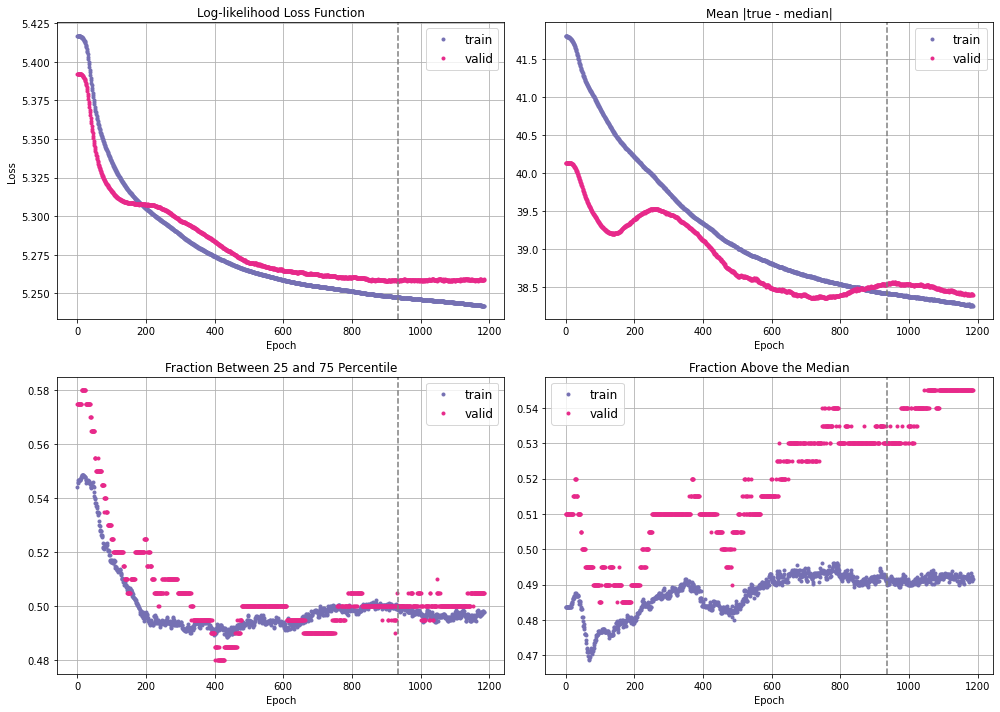

'longitude501_EPCP24_2014_shash2_network_seed_345_rng_seed_345'
Restoring model weights from the end of the best epoch: 1457.
Epoch 01707: early stopping
{'best_epoch': 1456,
 'elapsed_time': 46.2645788192749,
 'loss_train': 5.249485015869141,
 'loss_valid': 5.227136135101318,
 'network_seed': 345}


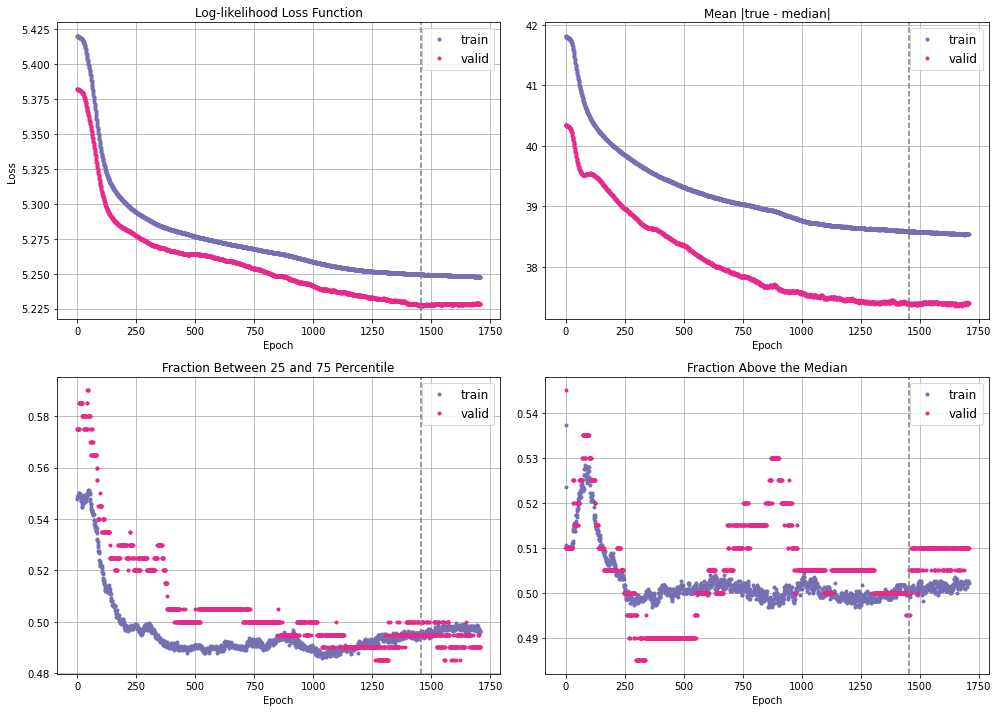

'longitude501_EPCP24_2015_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 668.
Epoch 00918: early stopping
{'best_epoch': 667,
 'elapsed_time': 23.945626974105835,
 'loss_train': 5.2041168212890625,
 'loss_valid': 5.22041130065918,
 'network_seed': 123}


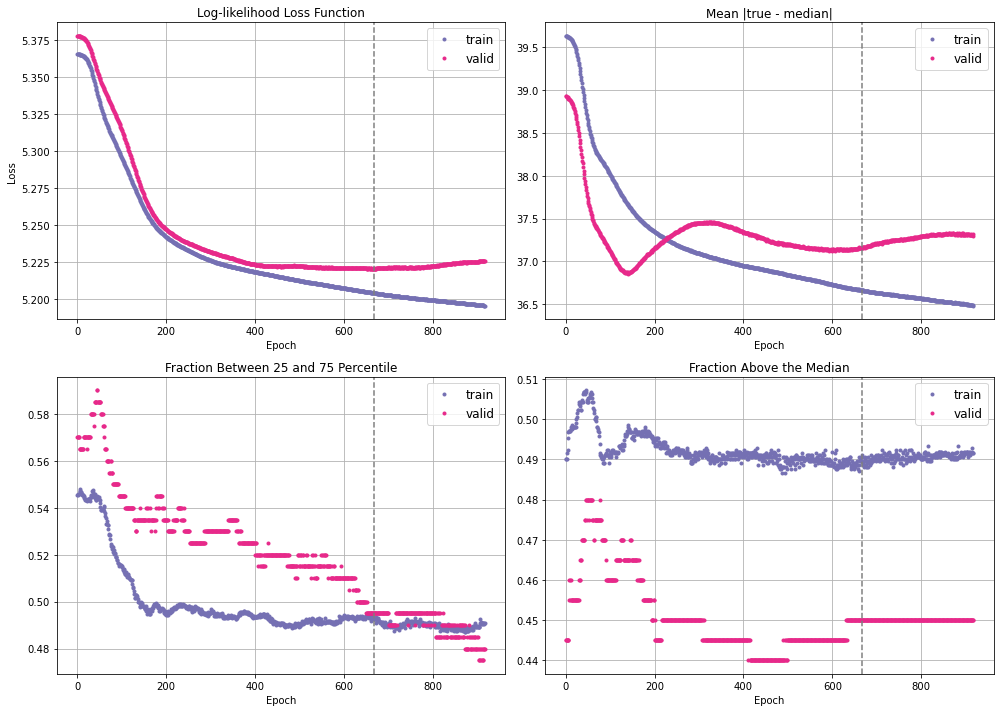

'longitude501_EPCP24_2015_shash2_network_seed_234_rng_seed_234'
Restoring model weights from the end of the best epoch: 762.
Epoch 01012: early stopping
{'best_epoch': 761,
 'elapsed_time': 26.044956922531128,
 'loss_train': 5.207086086273193,
 'loss_valid': 5.268234729766846,
 'network_seed': 234}


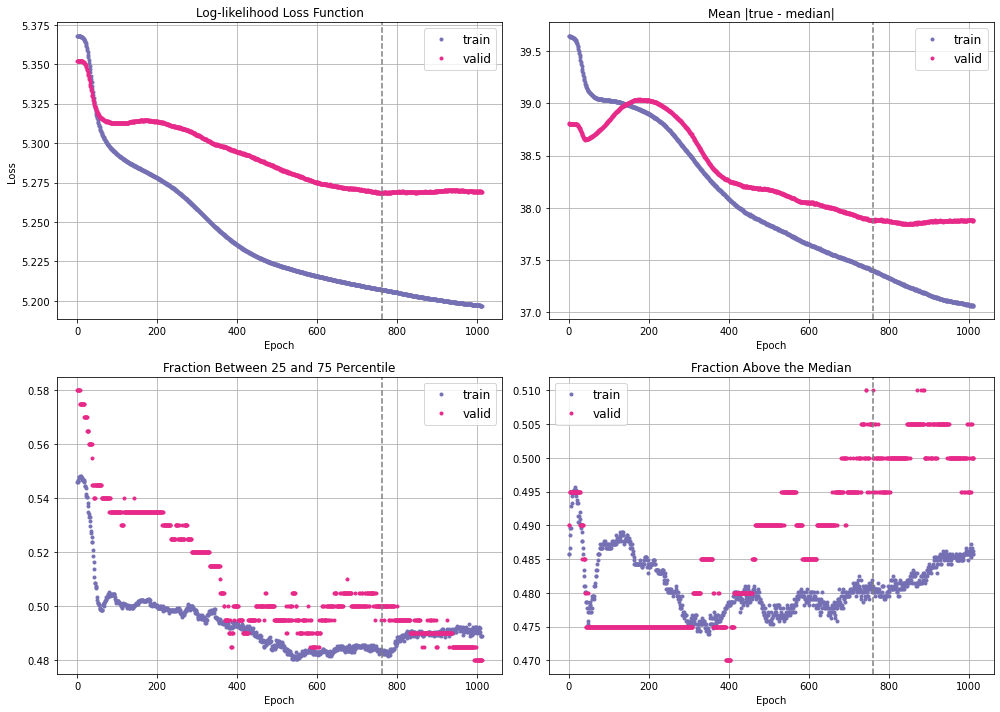

'longitude501_EPCP24_2015_shash2_network_seed_345_rng_seed_345'
Restoring model weights from the end of the best epoch: 569.
Epoch 00819: early stopping
{'best_epoch': 568,
 'elapsed_time': 20.830732107162476,
 'loss_train': 5.214375972747803,
 'loss_valid': 5.225701332092285,
 'network_seed': 345}


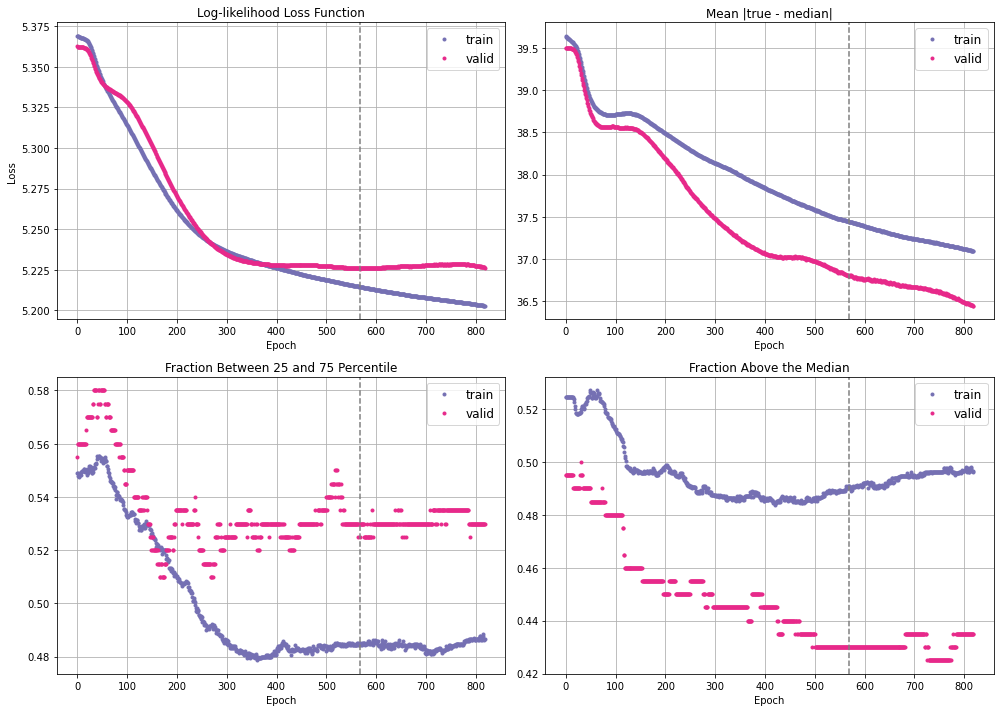

'longitude501_EPCP24_2016_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 543.
Epoch 00793: early stopping
{'best_epoch': 542,
 'elapsed_time': 21.876182794570923,
 'loss_train': 5.255342483520508,
 'loss_valid': 5.275864124298096,
 'network_seed': 123}


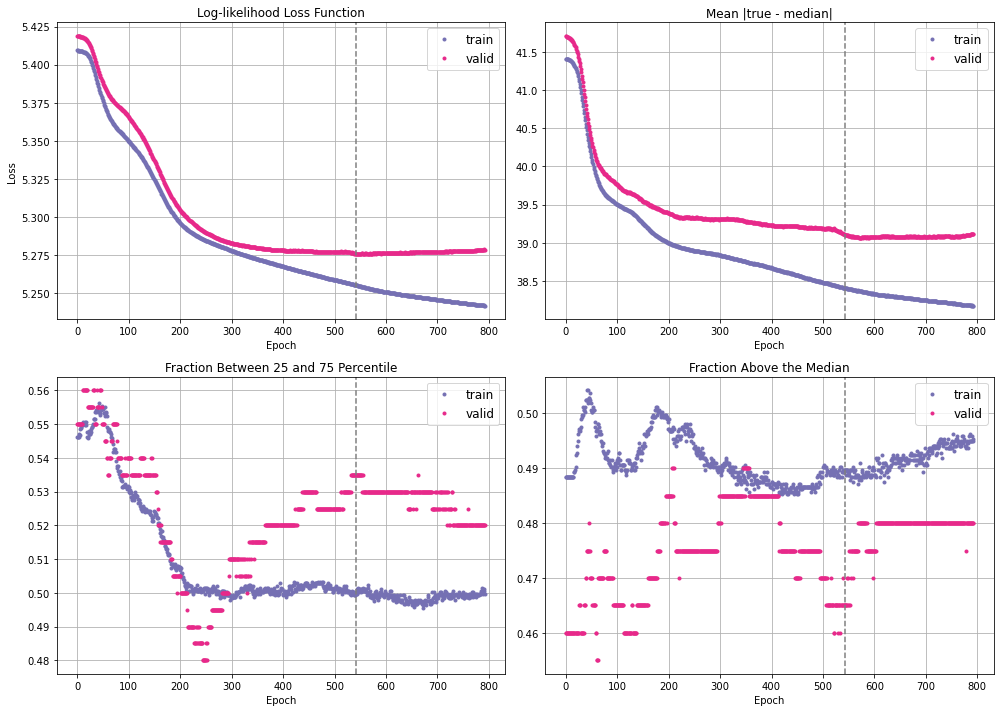

'longitude501_EPCP24_2016_shash2_network_seed_234_rng_seed_234'
Restoring model weights from the end of the best epoch: 1451.
Epoch 01701: early stopping
{'best_epoch': 1450,
 'elapsed_time': 44.366456031799316,
 'loss_train': 5.2520432472229,
 'loss_valid': 5.257307052612305,
 'network_seed': 234}


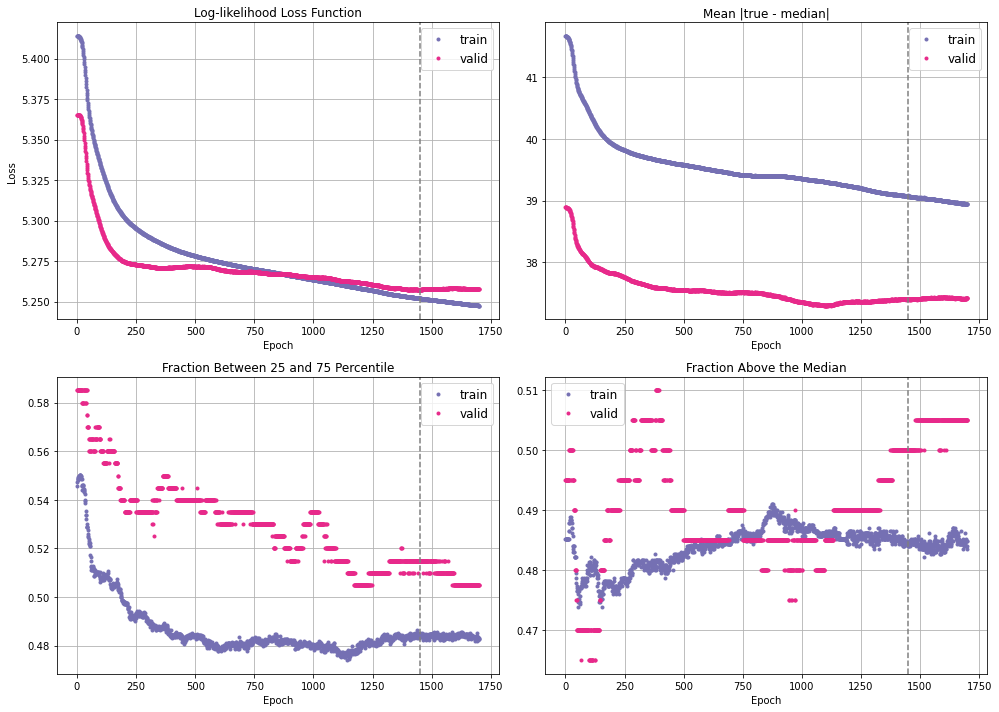

'longitude501_EPCP24_2016_shash2_network_seed_345_rng_seed_345'
Restoring model weights from the end of the best epoch: 708.
Epoch 00958: early stopping
{'best_epoch': 707,
 'elapsed_time': 25.277768850326538,
 'loss_train': 5.252260684967041,
 'loss_valid': 5.273105621337891,
 'network_seed': 345}


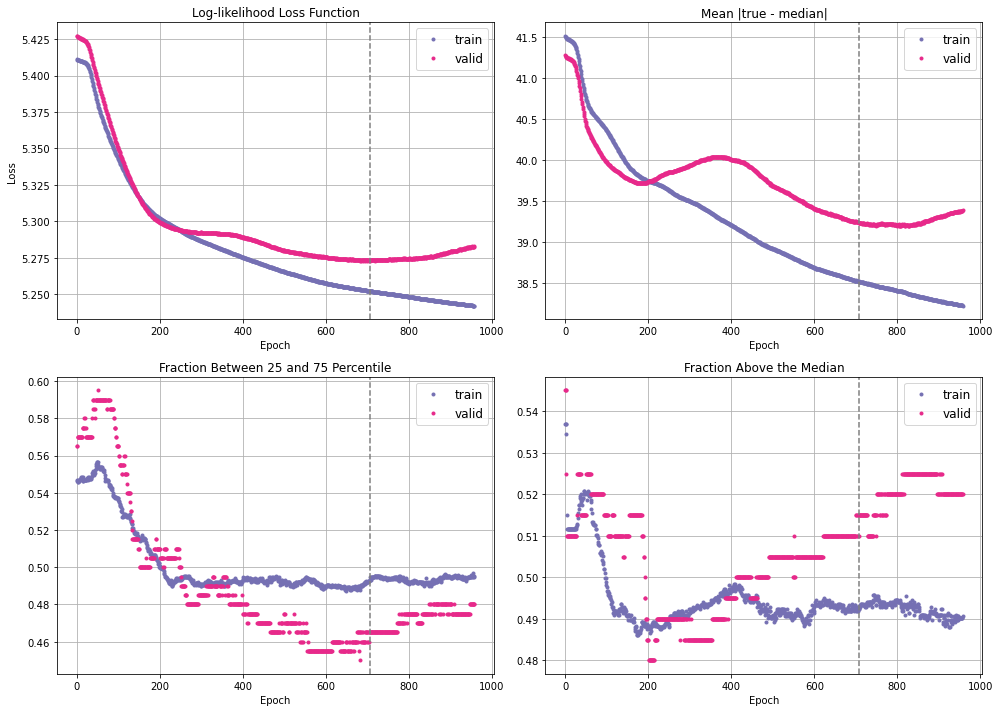

'longitude501_EPCP24_2017_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 627.
Epoch 00877: early stopping
{'best_epoch': 626,
 'elapsed_time': 24.012037754058838,
 'loss_train': 5.264400482177734,
 'loss_valid': 5.243510723114014,
 'network_seed': 123}


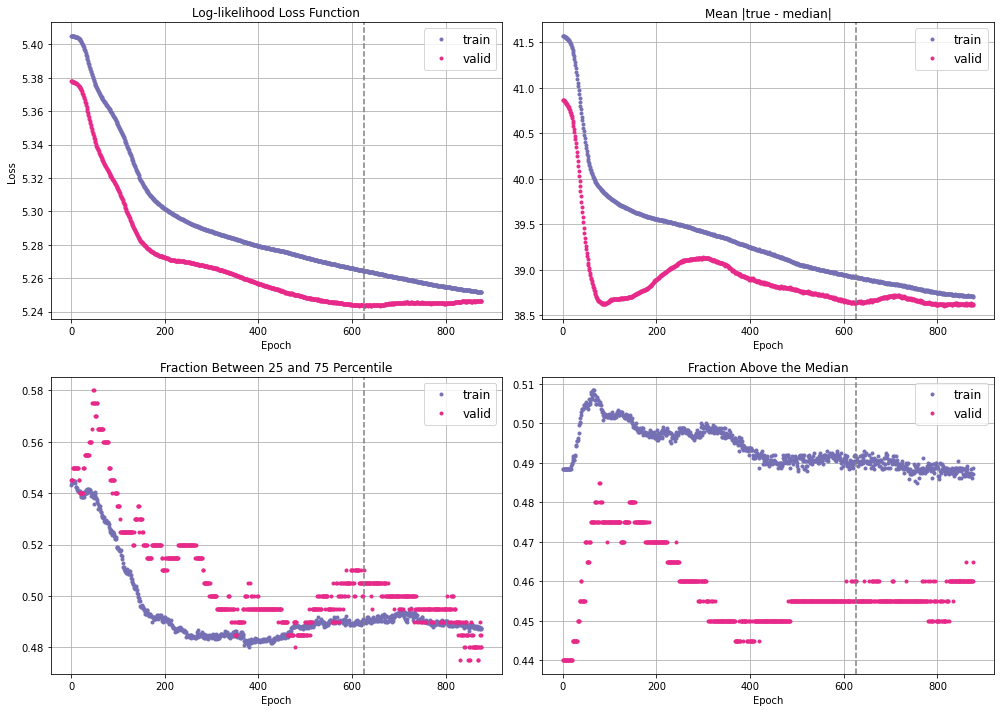

'longitude501_EPCP24_2017_shash2_network_seed_234_rng_seed_234'
Restoring model weights from the end of the best epoch: 1035.
Epoch 01285: early stopping
{'best_epoch': 1034,
 'elapsed_time': 34.79482412338257,
 'loss_train': 5.2599945068359375,
 'loss_valid': 5.244870662689209,
 'network_seed': 234}


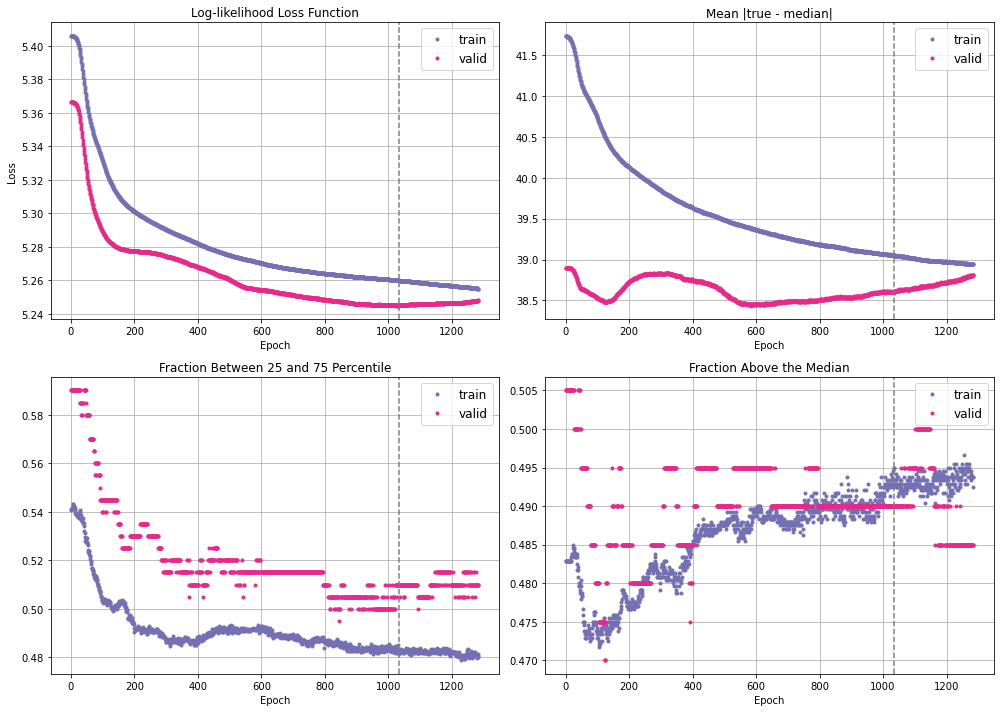

'longitude501_EPCP24_2017_shash2_network_seed_345_rng_seed_345'
Restoring model weights from the end of the best epoch: 2756.
Epoch 03006: early stopping
{'best_epoch': 2755,
 'elapsed_time': 80.55976104736328,
 'loss_train': 5.236281871795654,
 'loss_valid': 5.262444972991943,
 'network_seed': 345}


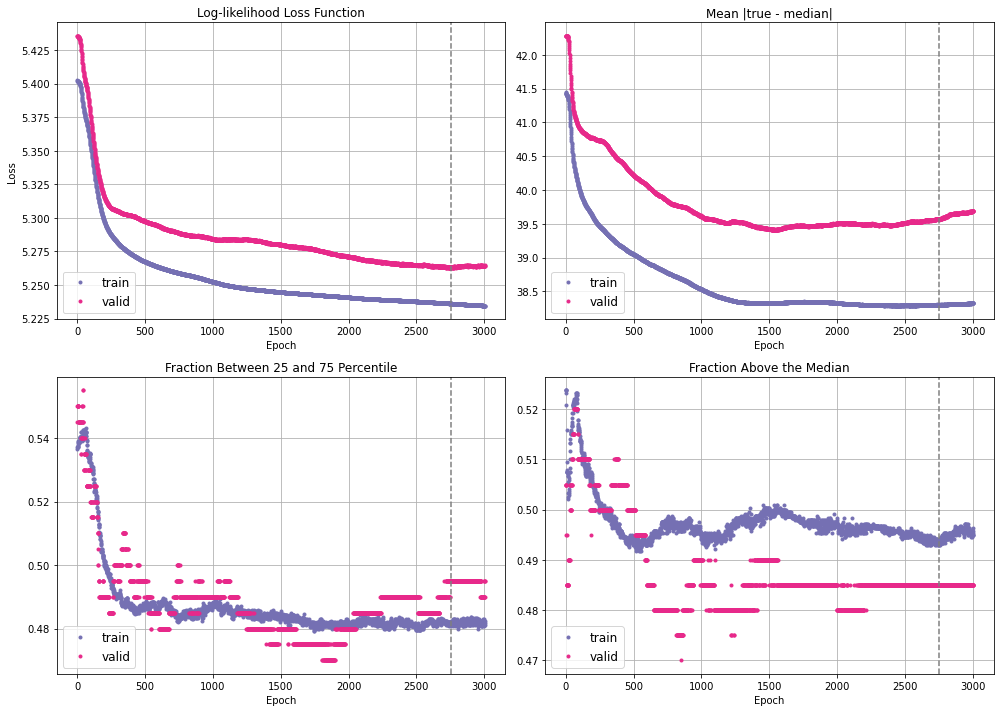

'longitude501_EPCP24_2018_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 444.
Epoch 00694: early stopping
{'best_epoch': 443,
 'elapsed_time': 17.740949869155884,
 'loss_train': 5.296143054962158,
 'loss_valid': 5.293652534484863,
 'network_seed': 123}


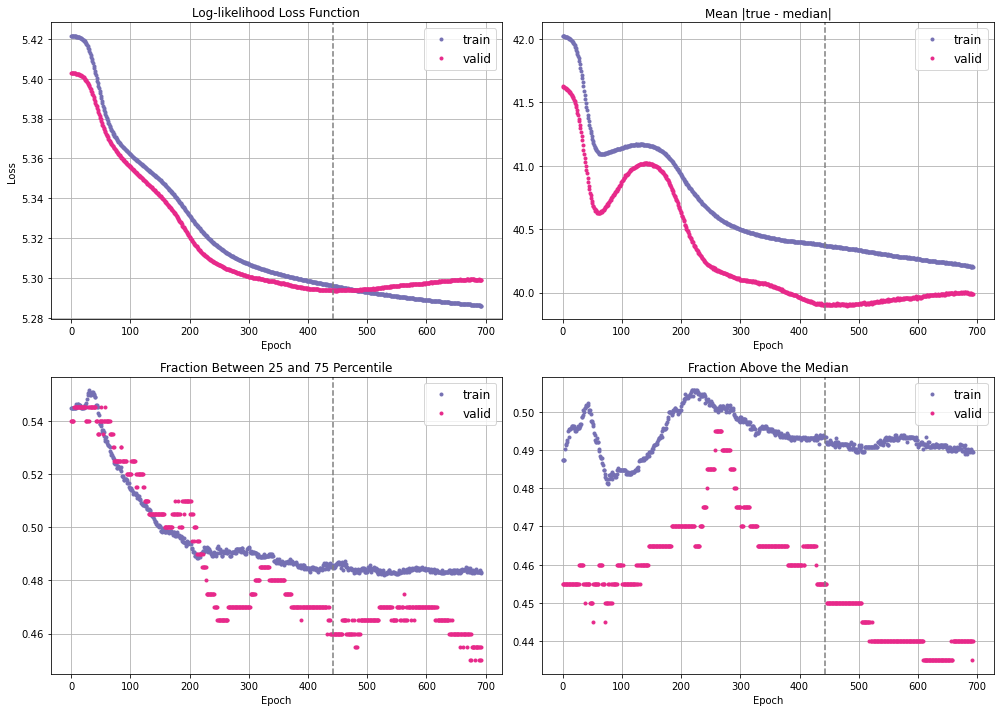

'longitude501_EPCP24_2018_shash2_network_seed_234_rng_seed_234'
Restoring model weights from the end of the best epoch: 614.
Epoch 00864: early stopping
{'best_epoch': 613,
 'elapsed_time': 22.38753318786621,
 'loss_train': 5.300147533416748,
 'loss_valid': 5.283587455749512,
 'network_seed': 234}


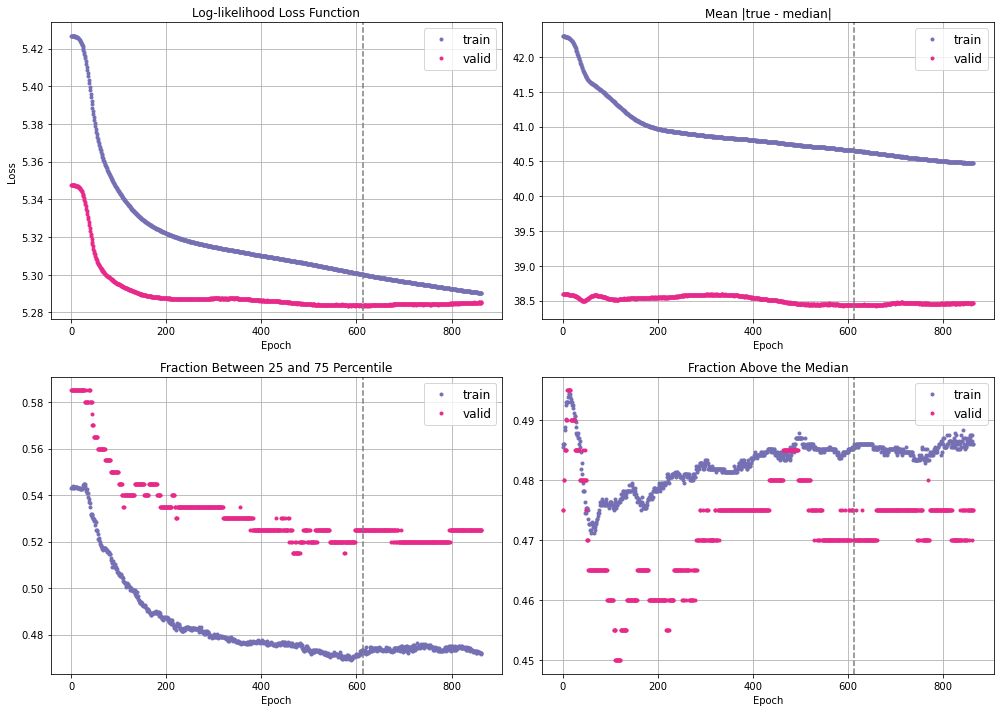

'longitude501_EPCP24_2018_shash2_network_seed_345_rng_seed_345'
Restoring model weights from the end of the best epoch: 205.
Epoch 00455: early stopping
{'best_epoch': 204,
 'elapsed_time': 12.237244129180908,
 'loss_train': 5.315088272094727,
 'loss_valid': 5.336185932159424,
 'network_seed': 345}


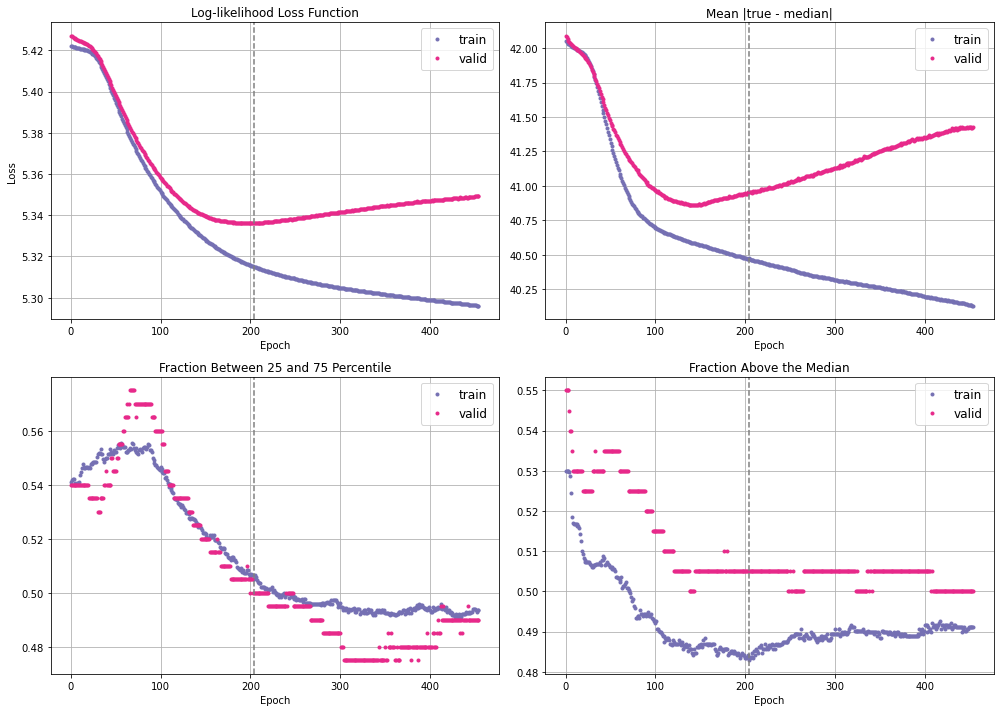

'longitude501_EPCP24_2019_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 2534.
Epoch 02784: early stopping
{'best_epoch': 2533,
 'elapsed_time': 76.32480573654175,
 'loss_train': 5.192217826843262,
 'loss_valid': 5.237247467041016,
 'network_seed': 123}


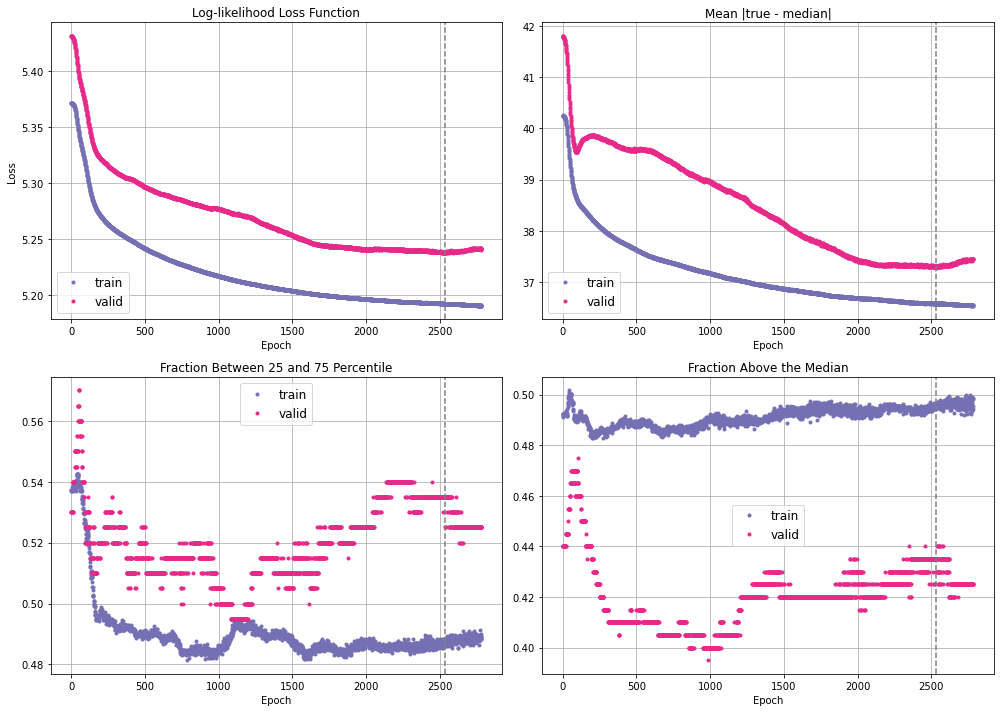

'longitude501_EPCP24_2019_shash2_network_seed_234_rng_seed_234'
Restoring model weights from the end of the best epoch: 614.
Epoch 00864: early stopping
{'best_epoch': 613,
 'elapsed_time': 24.00744891166687,
 'loss_train': 5.237502098083496,
 'loss_valid': 5.200162887573242,
 'network_seed': 234}


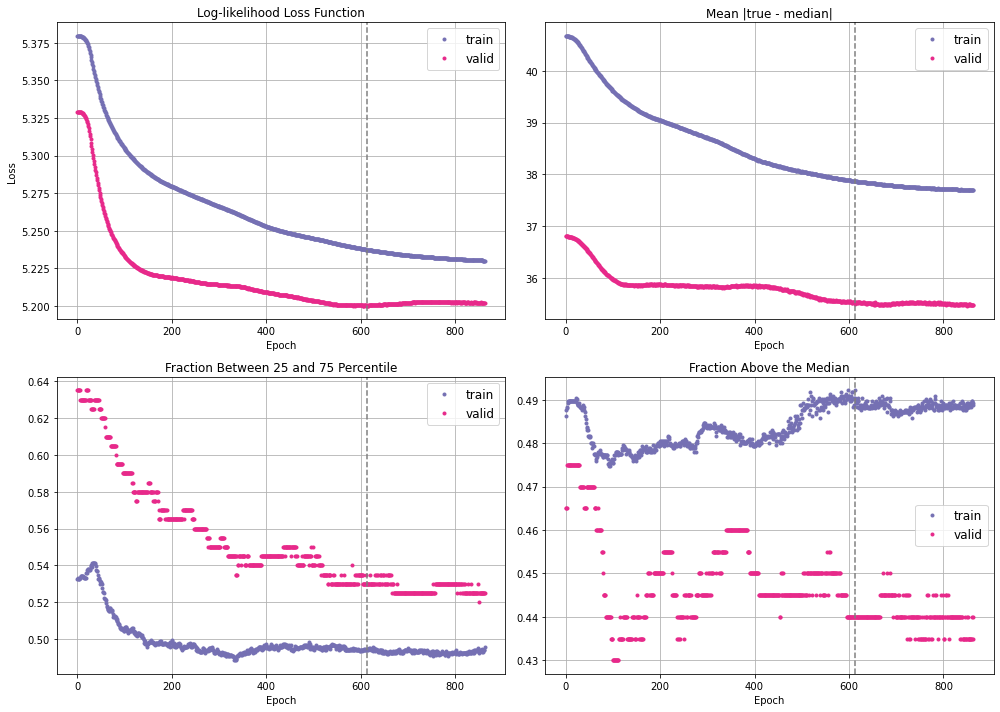

'longitude501_EPCP24_2019_shash2_network_seed_345_rng_seed_345'
Restoring model weights from the end of the best epoch: 649.
Epoch 00899: early stopping
{'best_epoch': 648,
 'elapsed_time': 25.21986675262451,
 'loss_train': 5.249115943908691,
 'loss_valid': 5.239184379577637,
 'network_seed': 345}


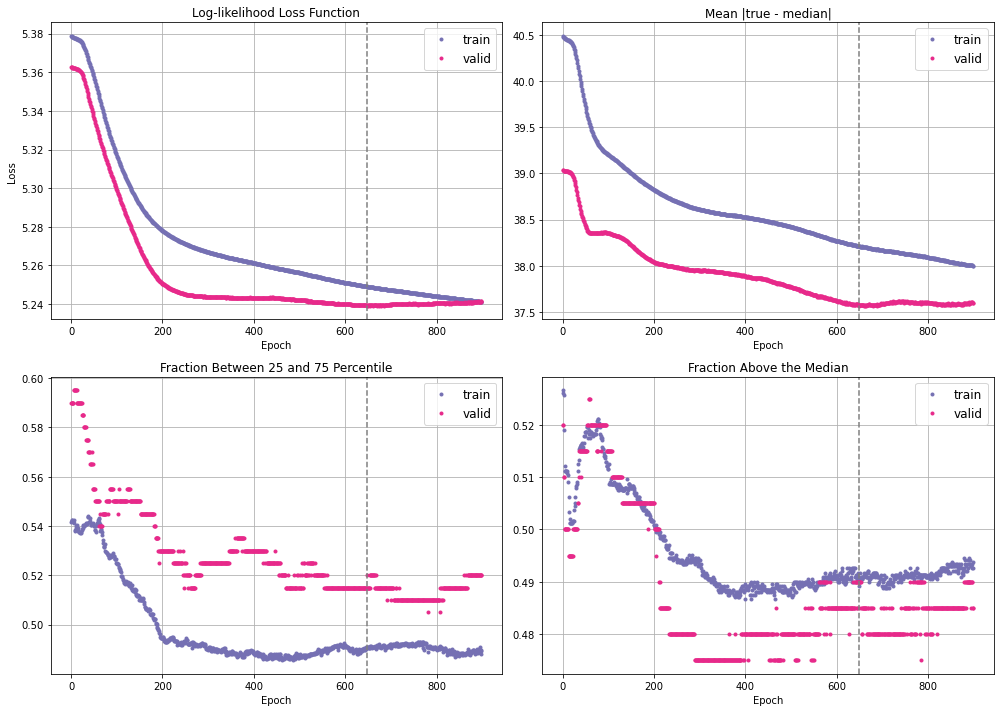

'longitude501_EPCP24_2020_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 798.
Epoch 01048: early stopping
{'best_epoch': 797,
 'elapsed_time': 30.000760078430176,
 'loss_train': 5.2486748695373535,
 'loss_valid': 5.225666522979736,
 'network_seed': 123}


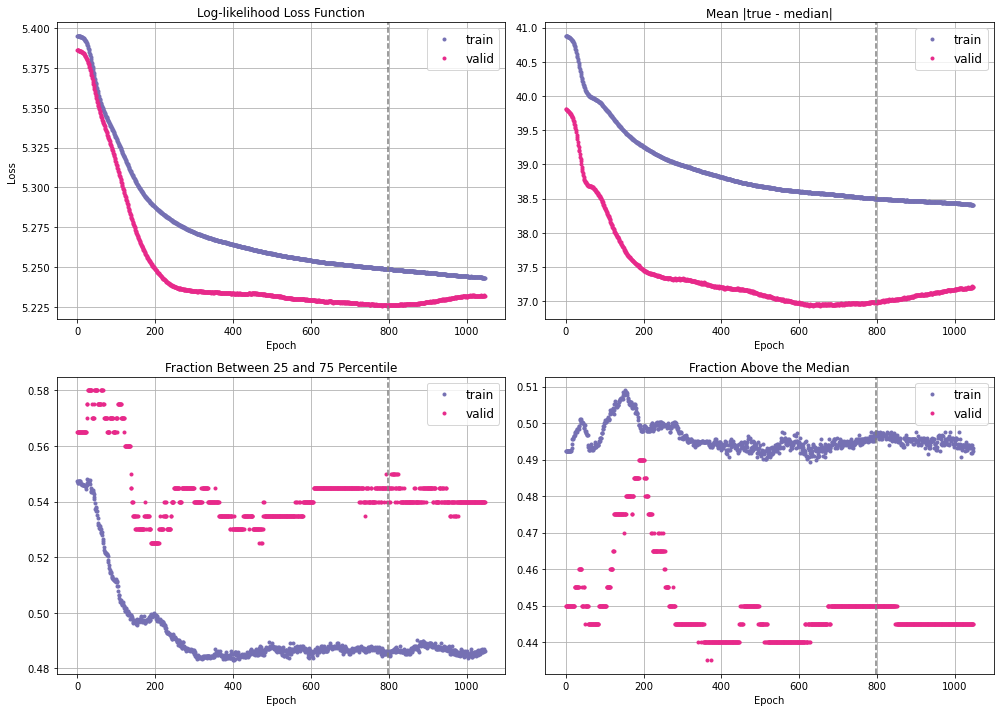

'longitude501_EPCP24_2020_shash2_network_seed_234_rng_seed_234'
Restoring model weights from the end of the best epoch: 1099.
Epoch 01349: early stopping
{'best_epoch': 1098,
 'elapsed_time': 37.96064019203186,
 'loss_train': 5.2459397315979,
 'loss_valid': 5.222700595855713,
 'network_seed': 234}


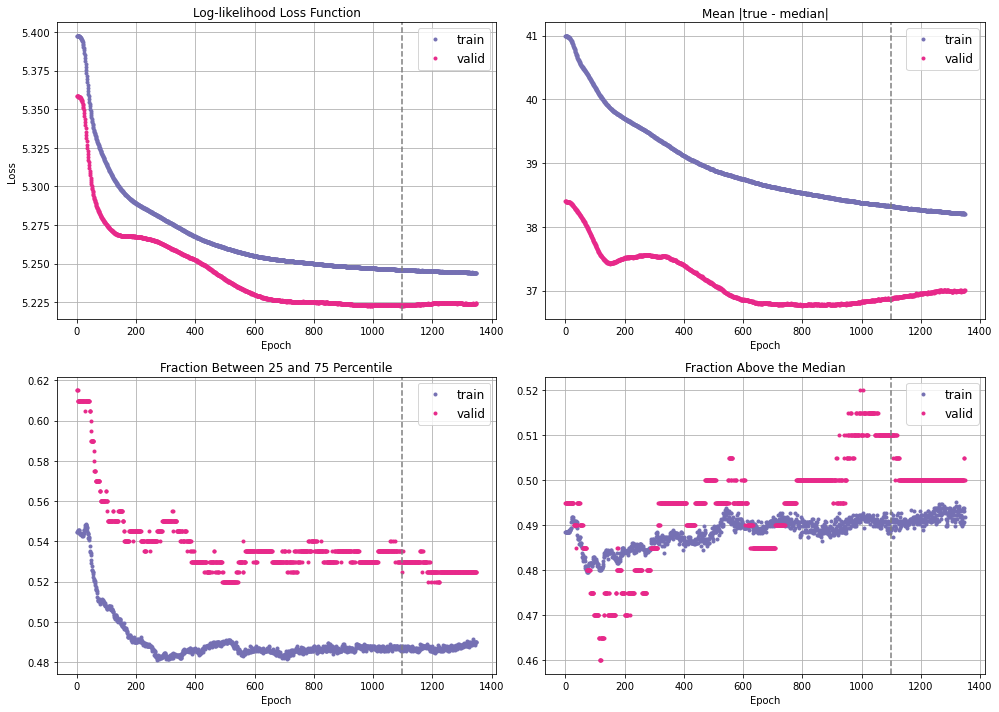

'longitude501_EPCP24_2020_shash2_network_seed_345_rng_seed_345'
Restoring model weights from the end of the best epoch: 1289.
Epoch 01539: early stopping
{'best_epoch': 1288,
 'elapsed_time': 43.11505937576294,
 'loss_train': 5.2406110763549805,
 'loss_valid': 5.264113903045654,
 'network_seed': 345}


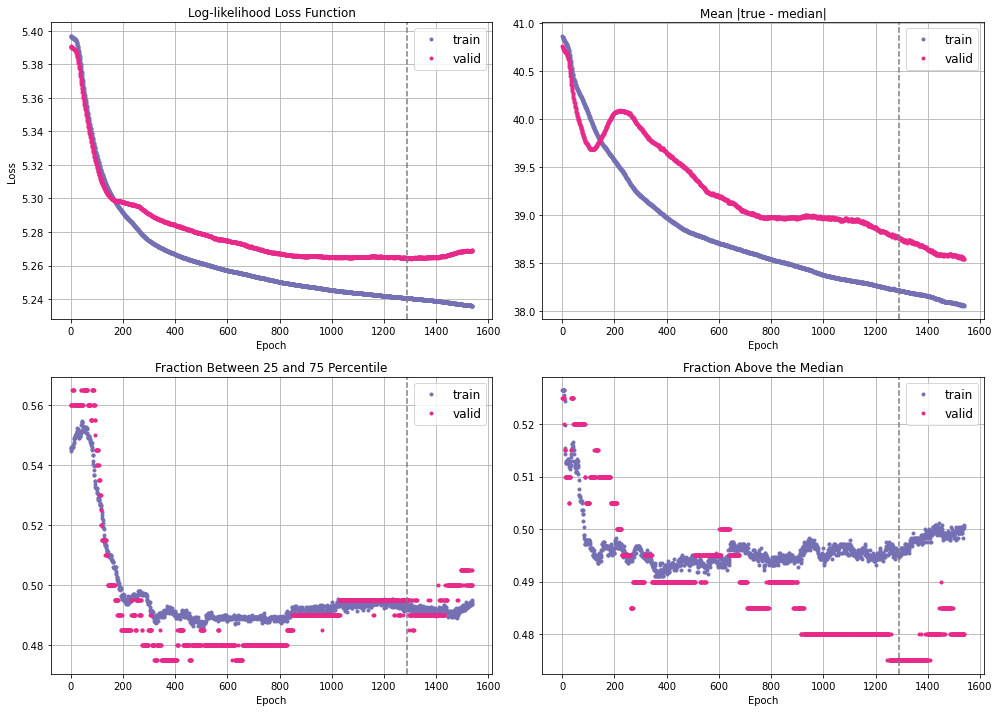

'longitude501_EPCP24_2021_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 705.
Epoch 00955: early stopping
{'best_epoch': 704,
 'elapsed_time': 26.767454147338867,
 'loss_train': 5.241456985473633,
 'loss_valid': 5.221742153167725,
 'network_seed': 123}


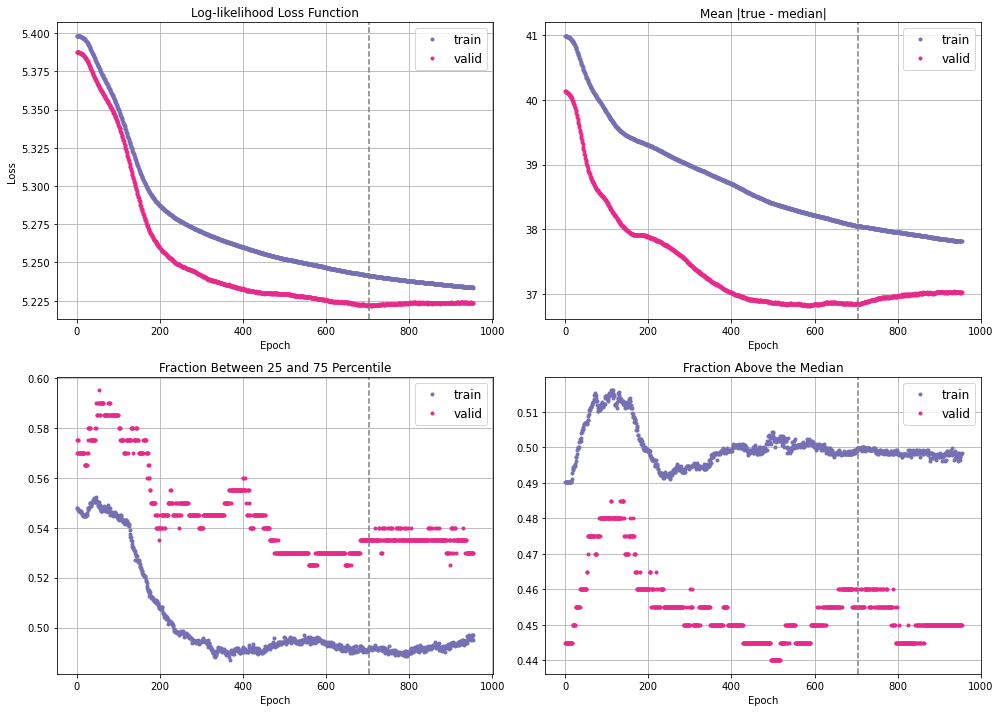

'longitude501_EPCP24_2021_shash2_network_seed_234_rng_seed_234'
Restoring model weights from the end of the best epoch: 1022.
Epoch 01272: early stopping
{'best_epoch': 1021,
 'elapsed_time': 35.27849793434143,
 'loss_train': 5.259957790374756,
 'loss_valid': 5.208032608032227,
 'network_seed': 234}


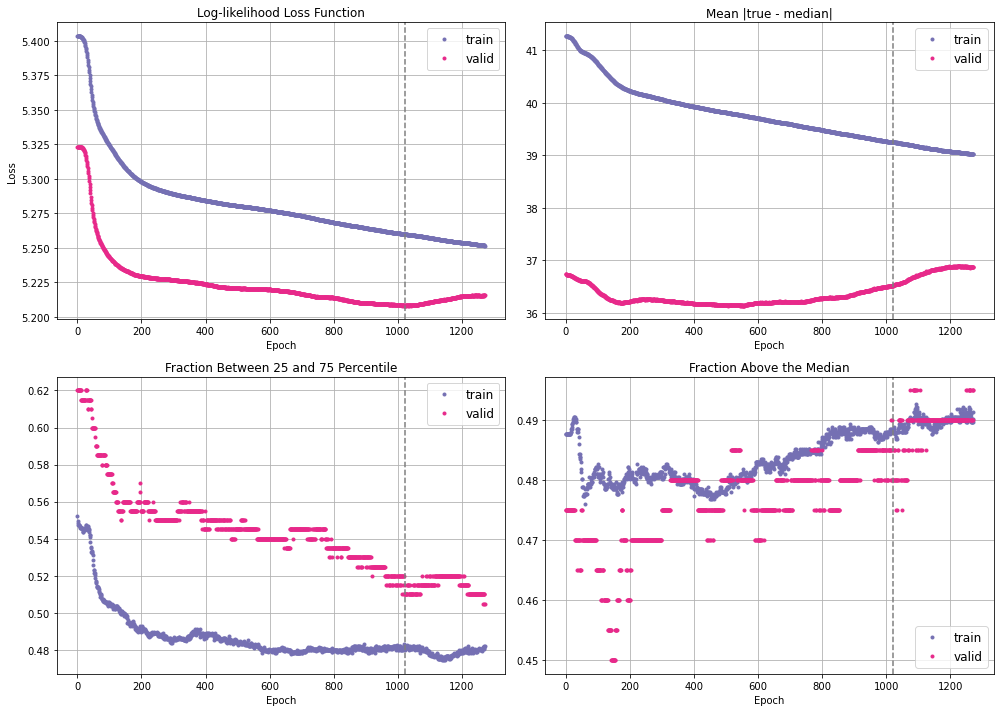

'longitude501_EPCP24_2021_shash2_network_seed_345_rng_seed_345'
Restoring model weights from the end of the best epoch: 1647.
Epoch 01897: early stopping
{'best_epoch': 1646,
 'elapsed_time': 52.11529994010925,
 'loss_train': 5.224642276763916,
 'loss_valid': 5.227632999420166,
 'network_seed': 345}


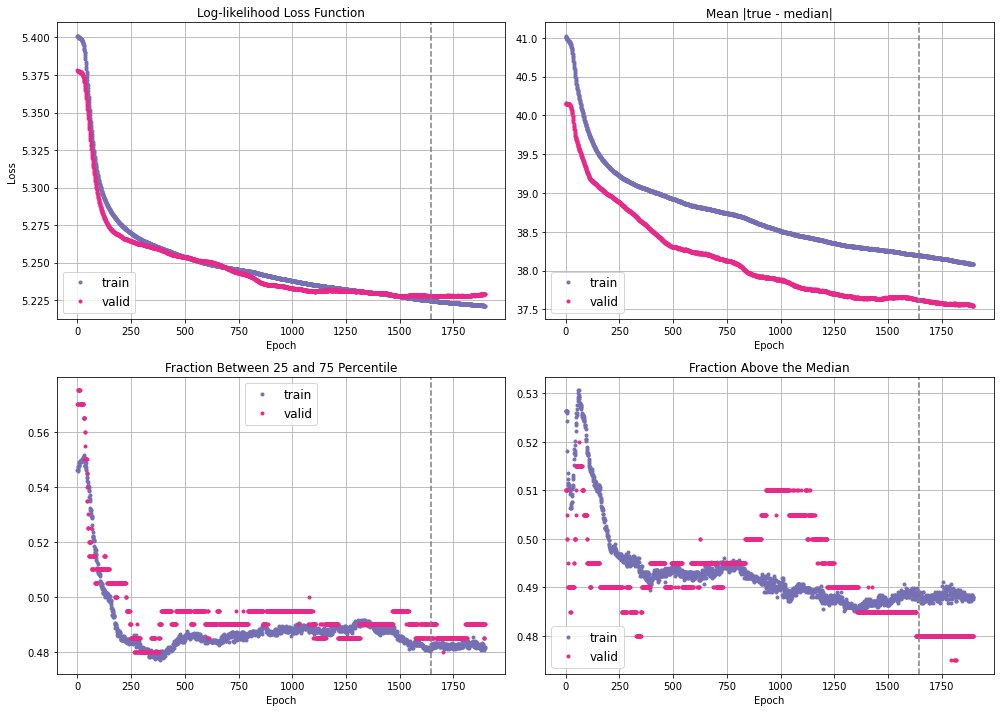

'latitude501_EPCP24_2013_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 1171.
Epoch 01421: early stopping
{'best_epoch': 1170,
 'elapsed_time': 38.969531774520874,
 'loss_train': 5.163888931274414,
 'loss_valid': 5.238402843475342,
 'network_seed': 123}


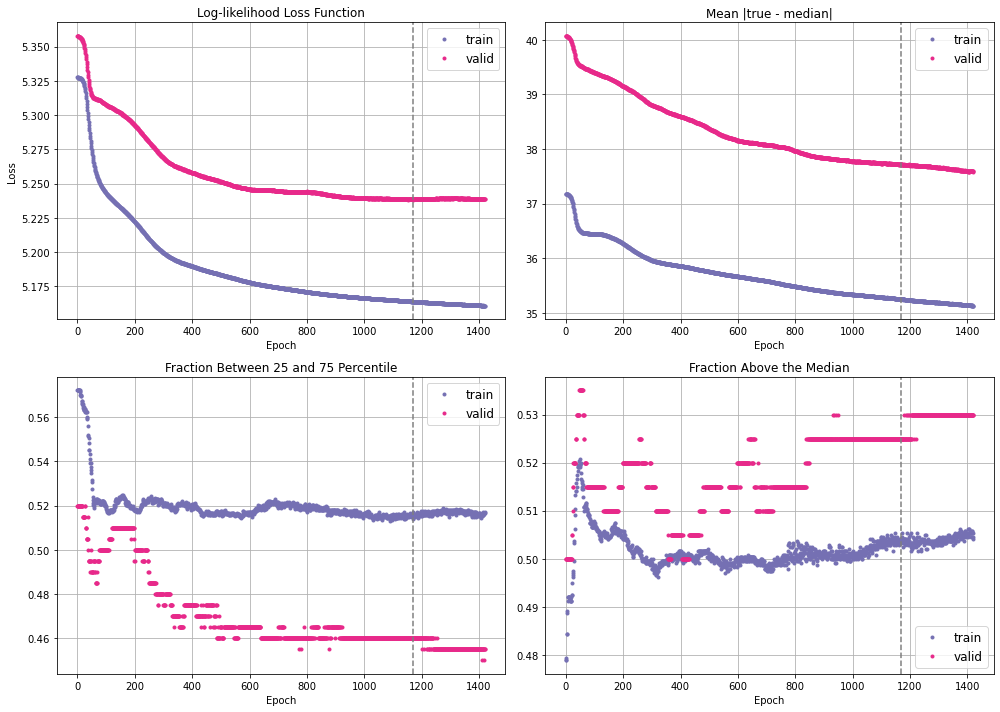

'latitude501_EPCP24_2013_shash2_network_seed_234_rng_seed_234'
Restoring model weights from the end of the best epoch: 529.
Epoch 00779: early stopping
{'best_epoch': 528,
 'elapsed_time': 21.77089500427246,
 'loss_train': 5.189303398132324,
 'loss_valid': 5.1615095138549805,
 'network_seed': 234}


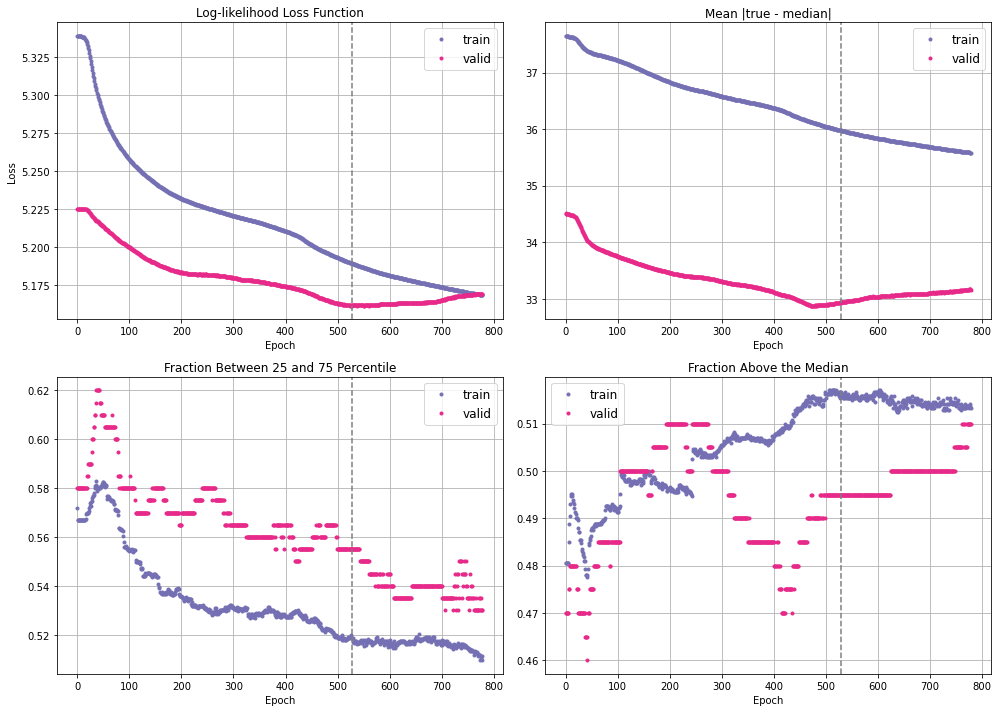

'latitude501_EPCP24_2013_shash2_network_seed_345_rng_seed_345'
Restoring model weights from the end of the best epoch: 67.
Epoch 00317: early stopping
{'best_epoch': 66,
 'elapsed_time': 8.585873126983643,
 'loss_train': 5.250468730926514,
 'loss_valid': 5.165262222290039,
 'network_seed': 345}


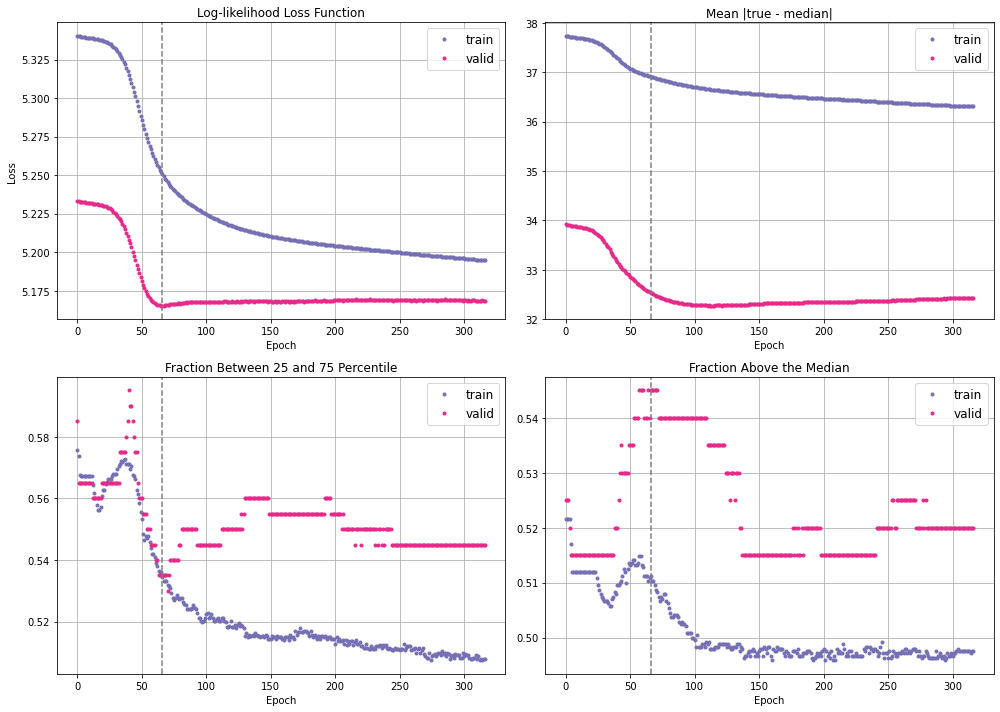

'latitude501_EPCP24_2014_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 300.
Epoch 00550: early stopping
{'best_epoch': 299,
 'elapsed_time': 14.13944697380066,
 'loss_train': 5.235959529876709,
 'loss_valid': 5.262197971343994,
 'network_seed': 123}


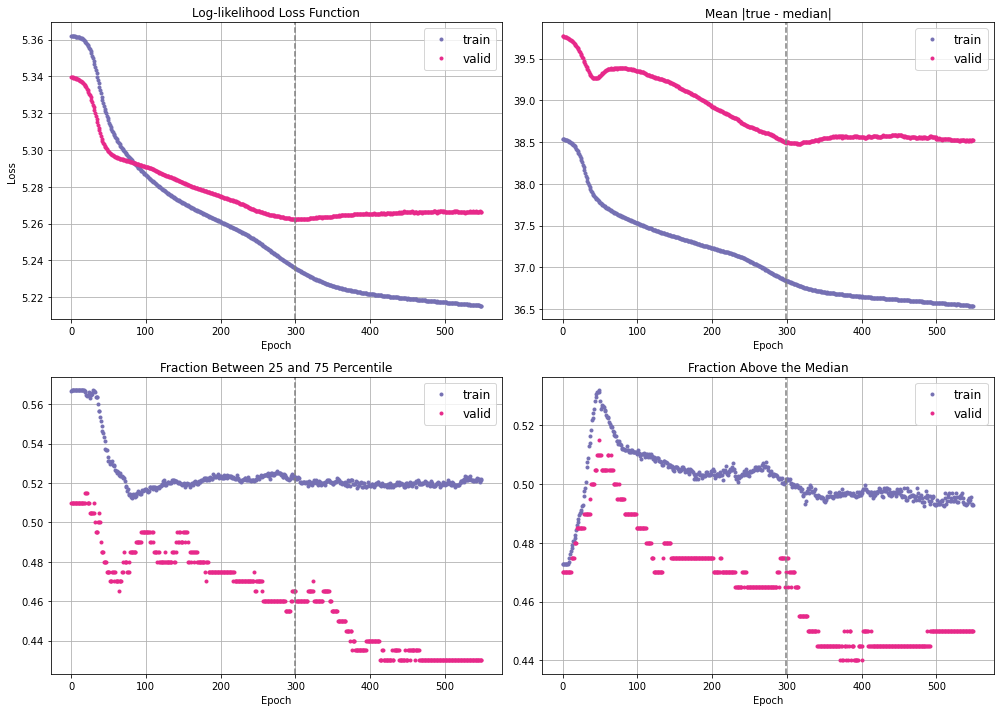

'latitude501_EPCP24_2014_shash2_network_seed_234_rng_seed_234'
Restoring model weights from the end of the best epoch: 633.
Epoch 00883: early stopping
{'best_epoch': 632,
 'elapsed_time': 22.816526174545288,
 'loss_train': 5.226274013519287,
 'loss_valid': 5.158684730529785,
 'network_seed': 234}


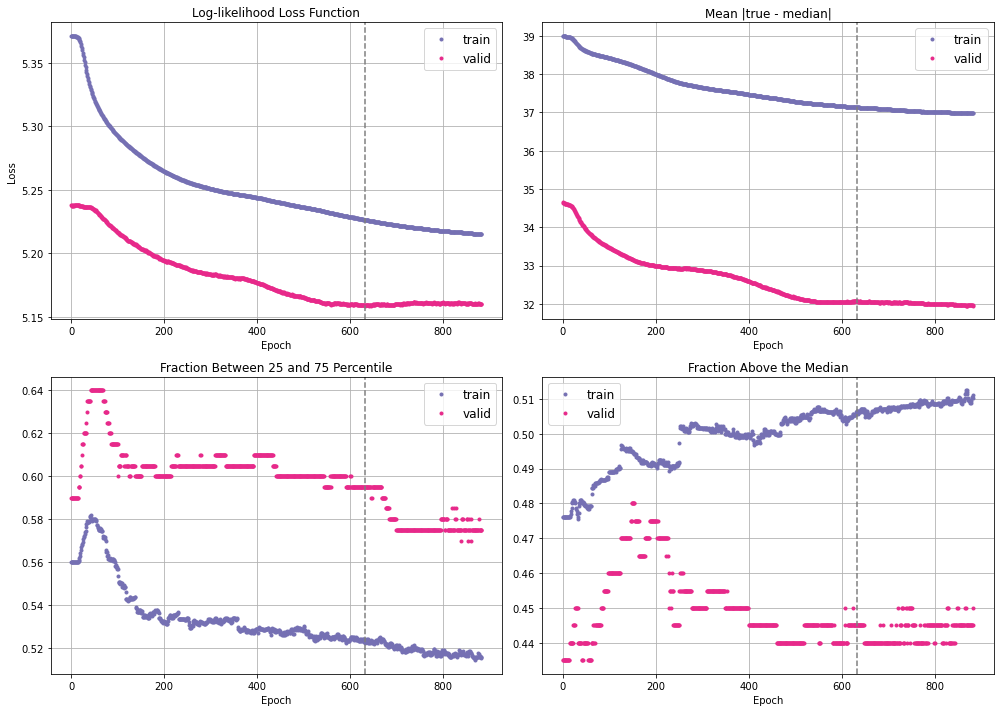

'latitude501_EPCP24_2014_shash2_network_seed_345_rng_seed_345'
Restoring model weights from the end of the best epoch: 207.
Epoch 00457: early stopping
{'best_epoch': 206,
 'elapsed_time': 11.486896276473999,
 'loss_train': 5.234282970428467,
 'loss_valid': 5.193693161010742,
 'network_seed': 345}


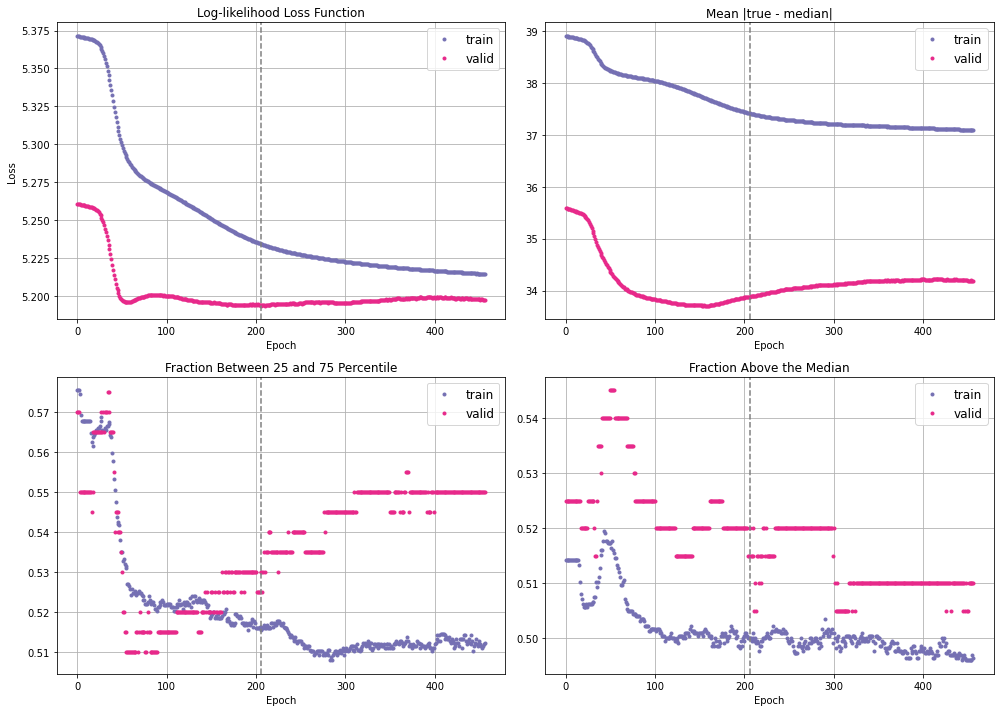

'latitude501_EPCP24_2015_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 540.
Epoch 00790: early stopping
{'best_epoch': 539,
 'elapsed_time': 18.66816997528076,
 'loss_train': 5.177317142486572,
 'loss_valid': 5.2064337730407715,
 'network_seed': 123}


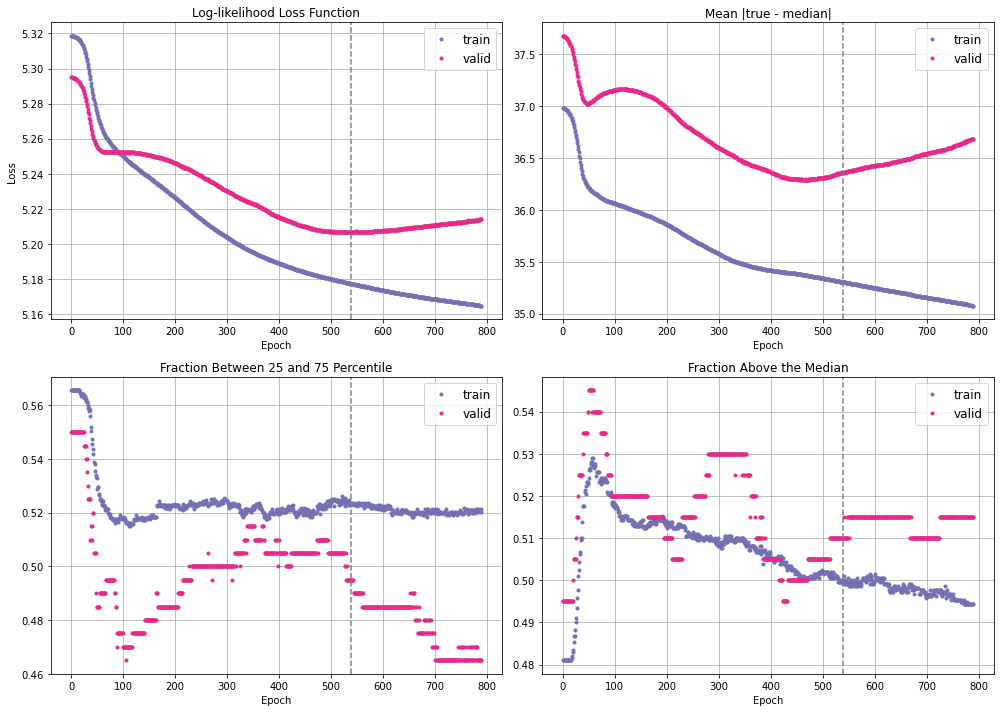

'latitude501_EPCP24_2015_shash2_network_seed_234_rng_seed_234'
Restoring model weights from the end of the best epoch: 76.
Epoch 00326: early stopping
{'best_epoch': 75,
 'elapsed_time': 7.9464287757873535,
 'loss_train': 5.236194133758545,
 'loss_valid': 5.161808967590332,
 'network_seed': 234}


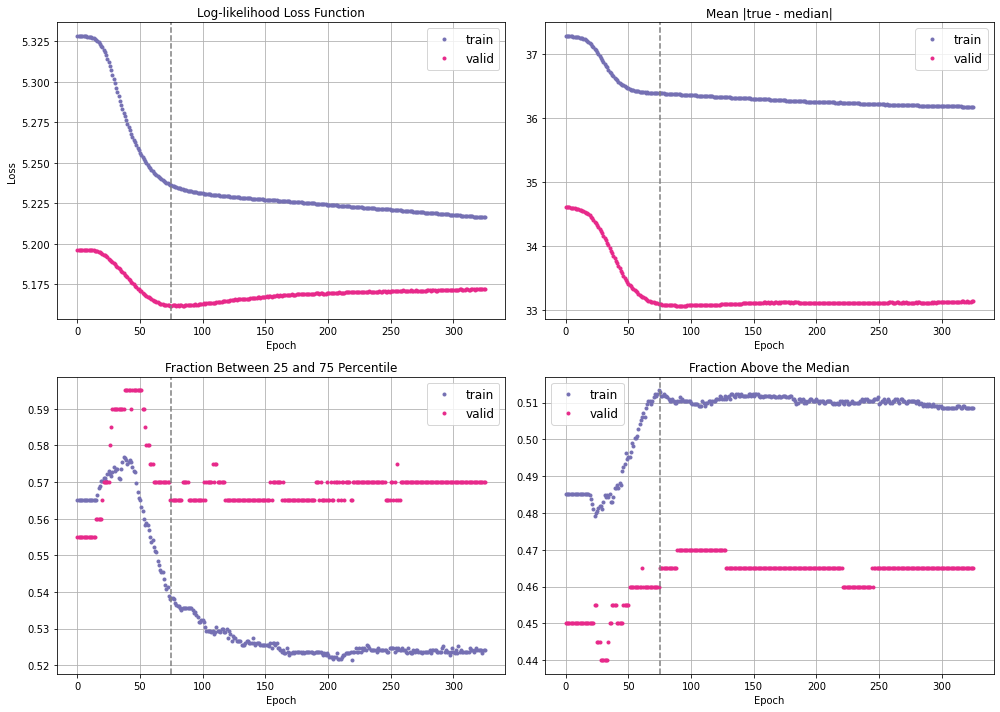

'latitude501_EPCP24_2015_shash2_network_seed_345_rng_seed_345'
Restoring model weights from the end of the best epoch: 179.
Epoch 00429: early stopping
{'best_epoch': 178,
 'elapsed_time': 10.273651123046875,
 'loss_train': 5.196903705596924,
 'loss_valid': 5.173734664916992,
 'network_seed': 345}


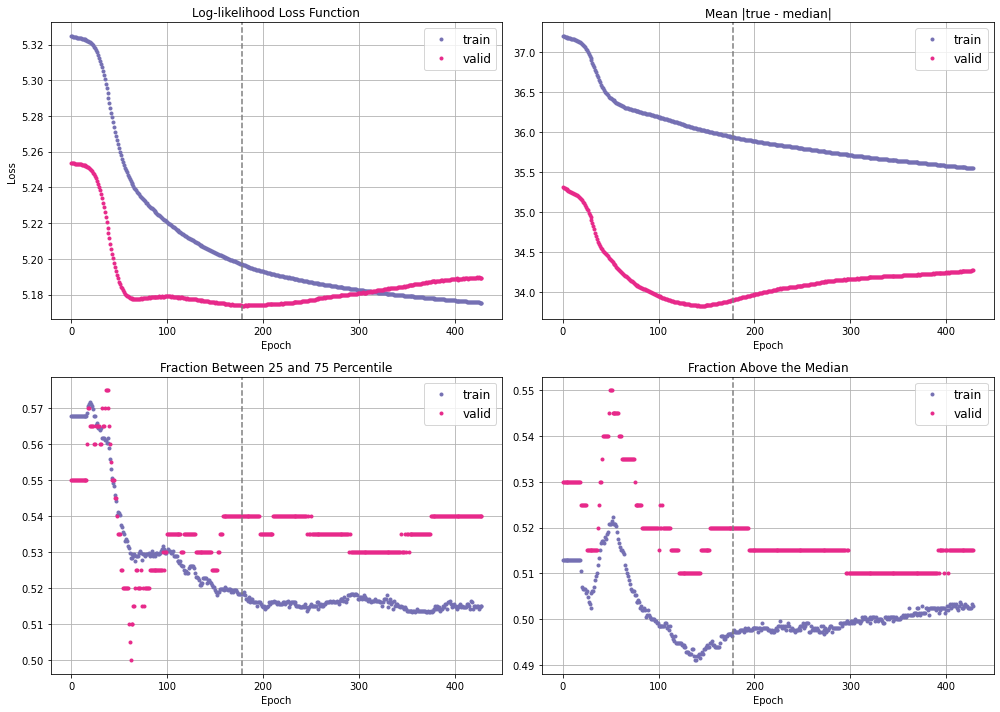

'latitude501_EPCP24_2016_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 1158.
Epoch 01408: early stopping
{'best_epoch': 1157,
 'elapsed_time': 34.36874794960022,
 'loss_train': 5.20005989074707,
 'loss_valid': 5.221735000610352,
 'network_seed': 123}


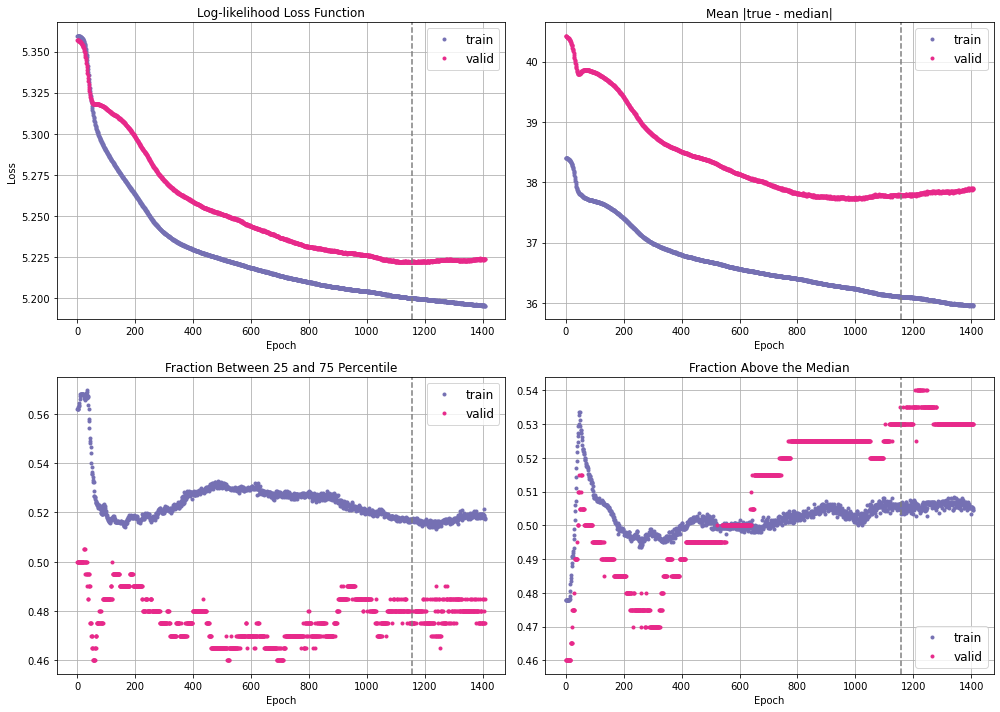

'latitude501_EPCP24_2016_shash2_network_seed_234_rng_seed_234'
Restoring model weights from the end of the best epoch: 433.
Epoch 00683: early stopping
{'best_epoch': 432,
 'elapsed_time': 17.27966594696045,
 'loss_train': 5.226120948791504,
 'loss_valid': 5.207615852355957,
 'network_seed': 234}


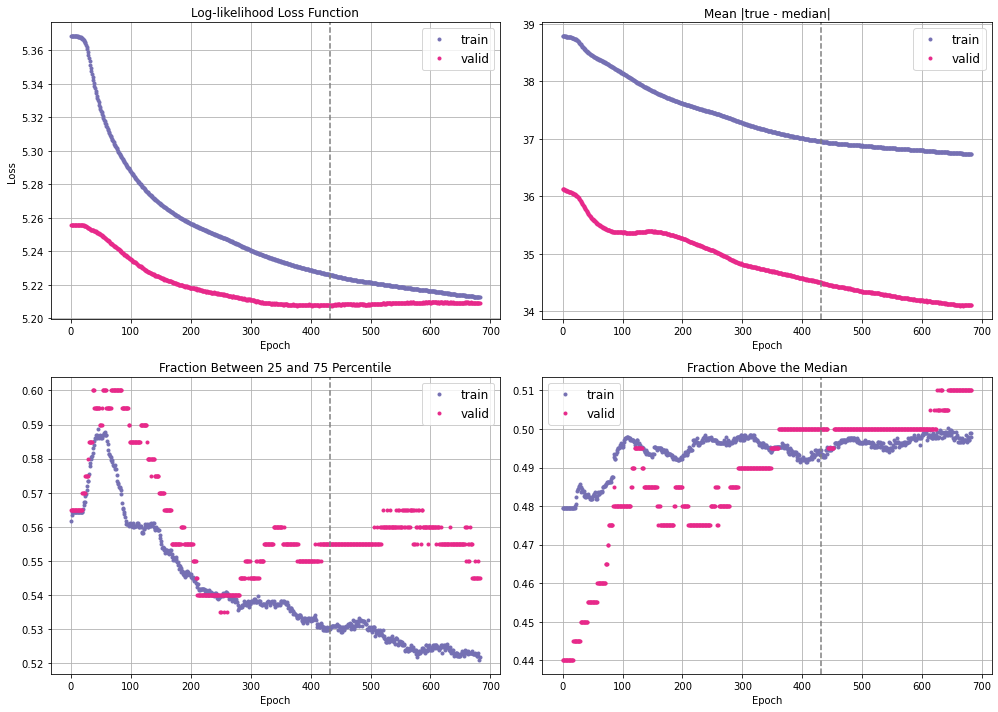

'latitude501_EPCP24_2016_shash2_network_seed_345_rng_seed_345'
Restoring model weights from the end of the best epoch: 328.
Epoch 00578: early stopping
{'best_epoch': 327,
 'elapsed_time': 14.541226148605347,
 'loss_train': 5.222836971282959,
 'loss_valid': 5.2063984870910645,
 'network_seed': 345}


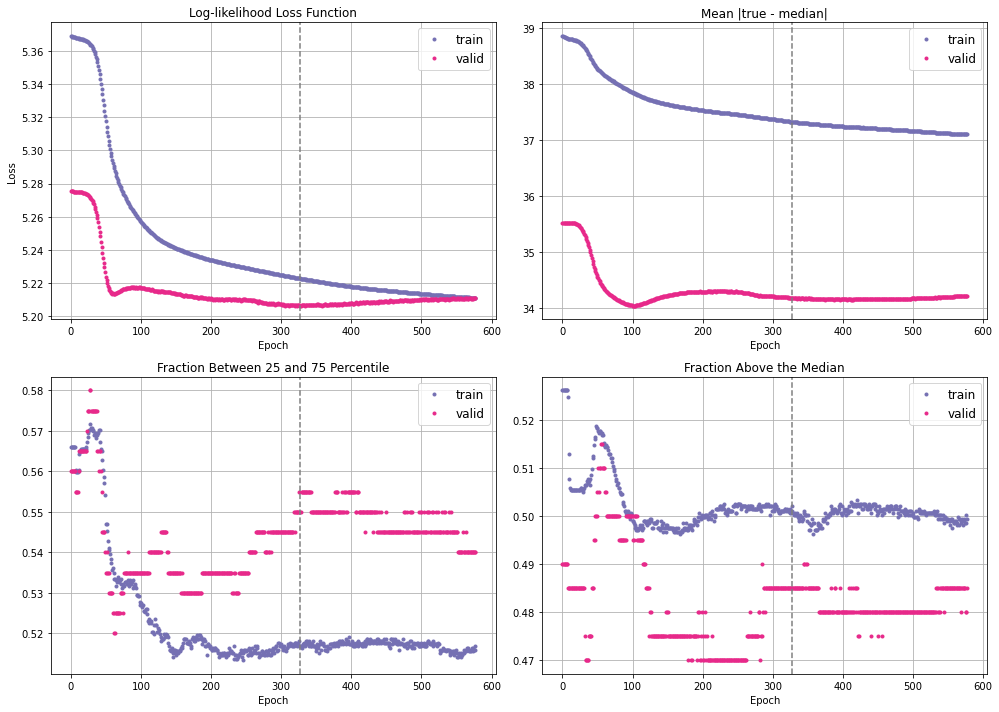

'latitude501_EPCP24_2017_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 1114.
Epoch 01364: early stopping
{'best_epoch': 1113,
 'elapsed_time': 35.227099895477295,
 'loss_train': 5.179556369781494,
 'loss_valid': 5.236642837524414,
 'network_seed': 123}


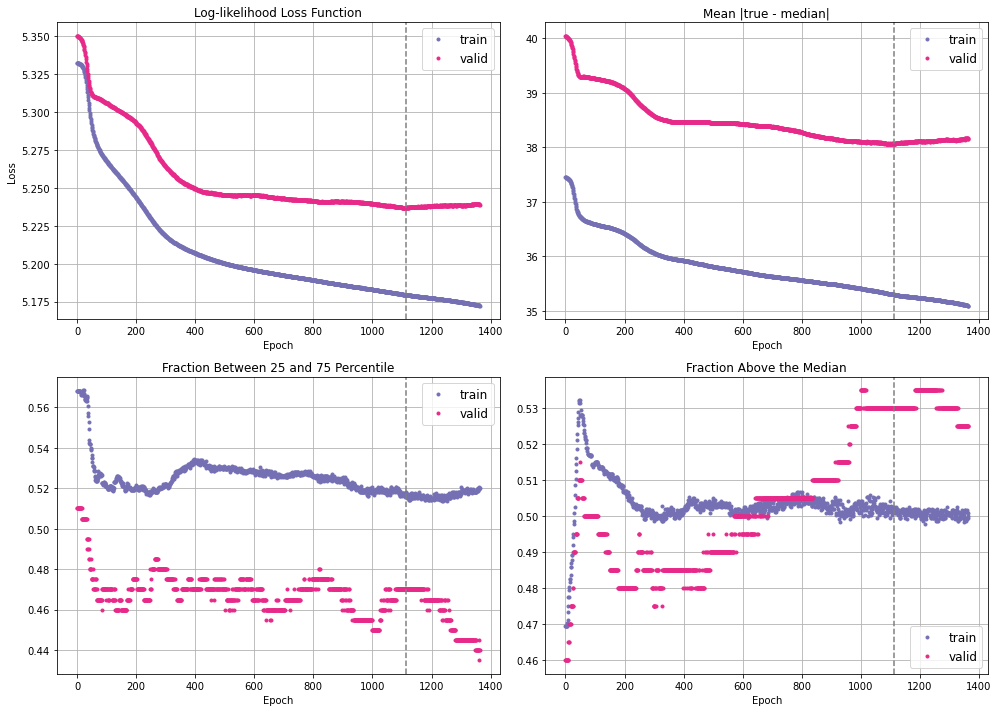

'latitude501_EPCP24_2017_shash2_network_seed_234_rng_seed_234'


In [ ]:
imp.reload(build_model)

for exp_name in EXP_NAME_LIST:
    settings = experiment_settings.get_settings(exp_name)

    # set testing data
    if settings["test_condition"] == "leave-one-out":
        TESTING_YEARS_LIST = np.arange(2013,2022)
    elif settings["test_condition"] == "years":
        TESTING_YEARS_LIST = (np.copy(settings["years_test"]))
    else:
        raise NotImplementError('no such testing condition')
        
    for testing_years in TESTING_YEARS_LIST:        
        # set testing year
        settings["years_test"] = (testing_years,)
        
        
        for rng_seed in settings['rng_seed_list']:
            settings['rng_seed'] = rng_seed

            # build the intensity data tensors
            (
                data_summary,        
                x_train,
                onehot_train,
                x_val,
                onehot_val,
                x_test,
                onehot_test,        
                x_valtest,
                onehot_valtest,
                df_train,
                df_val,
                df_test,
                df_valtest,
            ) = build_hurricane_data(DATA_PATH, settings, verbose=0)

            # define the callbacks
            earlystoping_callback = tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",
                mode="min",
                patience=settings["patience"],
                restore_best_weights=True,
                verbose=1,
            )

            training_callback = TrainingInstrumentation(
                x_train,
                onehot_train,
                interval=50,
            )

            callbacks = [earlystoping_callback, 
                         # training_callback,
                        ]

            # set network seed and train the model
            NETWORK_SEED_LIST = [settings["rng_seed"]]

            for network_seed in NETWORK_SEED_LIST:
                
                # set random seeds
                np.random.seed(rng_seed)
                random.seed(rng_seed)                            
                tf.random.set_seed(network_seed) 

                # Create the model name.
                model_name = (
                    exp_name + "_" + 
                    str(testing_years) + '_' +
                    settings["uncertainty_type"] + '_' + 
                    f"network_seed_{network_seed}_rng_seed_{settings['rng_seed']}"
                )

                # Make, compile, and train the model
                tf.keras.backend.clear_session()            
                model = build_model.make_model(
                    settings,
                    x_train,
                    onehot_train,
                    model_compile=True,
                )   
                # model.summary()

                # check if the model exists
                model_savename = MODEL_PATH + model_name + "_weights.h5"
                if os.path.exists(model_savename) and OVERWRITE_MODEL==False:
                    # print(model_savename + 'exists. Skipping...')
                    continue

                # train the network
                pprint.pprint(model_name)
                start_time = time.time()
                history = model.fit(
                    x_train,
                    onehot_train,
                    validation_data=(x_val, onehot_val),
                    batch_size=settings["batch_size"],
                    epochs=settings["n_epochs"],
                    shuffle=True,
                    verbose=0,
                    callbacks=callbacks,
                )
                stop_time = time.time()

                # Display the results, and save the model rum.
                best_epoch = np.argmin(history.history["val_loss"])
                fit_summary = {
                    "network_seed": network_seed,
                    "elapsed_time": stop_time - start_time,
                    "best_epoch": best_epoch,
                    "loss_train": history.history["loss"][best_epoch],
                    "loss_valid": history.history["val_loss"][best_epoch],
                }
                pprint.pprint(fit_summary, width=80)
                plot_history(history, model_name)

                save_model_run(
                    data_summary,
                    fit_summary,
                    model,
                    MODEL_PATH,
                    model_name,
                    settings,
                    __version__,
                )

In [ ]:
2+2